In [126]:
import pandas as pd
import numpy as np

In [127]:
data = pd.read_csv("C:\\Users\\Anuj Kumar\\Desktop\\Machine Learning\\datasets\\Travel.csv")

In [128]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

In [129]:
data.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [130]:
data.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='str')

In [131]:
data["TotalVisitors"] = data["NumberOfPersonVisiting"]+data["NumberOfChildrenVisiting"]
data = data.drop(columns=["NumberOfPersonVisiting","NumberOfChildrenVisiting"])


In [132]:
data.dtypes

CustomerID                  int64
ProdTaken                   int64
Age                       float64
TypeofContact                 str
CityTier                    int64
DurationOfPitch           float64
Occupation                    str
Gender                        str
NumberOfFollowups         float64
ProductPitched                str
PreferredPropertyStar     float64
MaritalStatus                 str
NumberOfTrips             float64
Passport                    int64
PitchSatisfactionScore      int64
OwnCar                      int64
Designation                   str
MonthlyIncome             float64
TotalVisitors             float64
dtype: object

In [133]:
data.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                       226
TypeofContact              25
CityTier                    0
DurationOfPitch           251
Occupation                  0
Gender                      0
NumberOfFollowups          45
ProductPitched              0
PreferredPropertyStar      26
MaritalStatus               0
NumberOfTrips             140
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
Designation                 0
MonthlyIncome             233
TotalVisitors              66
dtype: int64

In [134]:
data["Age"].median()


np.float64(36.0)

In [135]:
data["MonthlyIncome"].median()

np.float64(22347.0)

In [136]:
data["NumberOfFollowups"].median()

np.float64(4.0)

In [137]:

for feature in data.columns:
    if data[feature].isnull().sum() > 0:
        if data[feature].dtypes == 'float64' or data[feature].dtypes == "int64":
            data[feature] = data[feature].fillna(data[feature].median())

        else:
            data[feature] = data[feature].fillna(data[feature].mode()[0])



In [138]:
data.isnull().sum()

CustomerID                0
ProdTaken                 0
Age                       0
TypeofContact             0
CityTier                  0
DurationOfPitch           0
Occupation                0
Gender                    0
NumberOfFollowups         0
ProductPitched            0
PreferredPropertyStar     0
MaritalStatus             0
NumberOfTrips             0
Passport                  0
PitchSatisfactionScore    0
OwnCar                    0
Designation               0
MonthlyIncome             0
TotalVisitors             0
dtype: int64

In [139]:
data["Gender"].unique()

<StringArray>
['Female', 'Male', 'Fe Male']
Length: 3, dtype: str

In [140]:
data["MaritalStatus"].unique()

<StringArray>
['Single', 'Divorced', 'Married', 'Unmarried']
Length: 4, dtype: str

In [141]:
data["MaritalStatus"] = data["MaritalStatus"].replace("Single","Unmarried")
data["Gender"] = data["Gender"].replace("Fe Male","Female")

In [142]:
data["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [143]:
data["MaritalStatus"].unique()

<StringArray>
['Unmarried', 'Divorced', 'Married']
Length: 3, dtype: str

In [144]:
print(data["TypeofContact"].unique())

<StringArray>
['Self Enquiry', 'Company Invited']
Length: 2, dtype: str


In [145]:
data["Designation"].unique()

<StringArray>
['Manager', 'Executive', 'Senior Manager', 'AVP', 'VP']
Length: 5, dtype: str

In [146]:
data.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfFollowups',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'Designation', 'MonthlyIncome', 'TotalVisitors'],
      dtype='str')

In [147]:
data.drop('CustomerID',axis=1,inplace=True)

In [148]:
data.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfFollowups', 'ProductPitched',
       'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'Designation', 'MonthlyIncome',
       'TotalVisitors'],
      dtype='str')

In [149]:
data.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitors
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [150]:
X = data.drop("ProdTaken",axis = 1)
y = data["ProdTaken"]

In [151]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitors
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [152]:
y

0       1
1       0
2       1
3       0
4       0
       ..
4883    1
4884    1
4885    1
4886    1
4887    1
Name: ProdTaken, Length: 4888, dtype: int64

In [153]:
num_cols = X.select_dtypes(exclude="object").columns
cat_cols = X.select_dtypes(include="object").columns

C:\Users\Anuj Kumar\AppData\Local\Temp\ipykernel_18888\1572156622.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [154]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
std = StandardScaler()
onehot = OneHotEncoder(drop='first',handle_unknown="ignore")
preprocess = ColumnTransformer([
    ("StandardScaler",std,num_cols),
    ("OneHotEncoder",onehot,cat_cols)
])

In [155]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('StandardScaler', ...), ('OneHotEncoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [156]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
X_train.shape,X_test.shape

((3666, 17), (1222, 17))

In [157]:
X_preprocessed = preprocess.fit_transform(X_train)

In [158]:
X_preprocessed.shape

(3666, 26)

In [159]:
y_train.shape

(3666,)

In [160]:
X_test_preprocessed = preprocess.transform(X_test)

In [161]:
X_preprocessed

array([[-0.70893617, -0.72170819, -0.6533179 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.15440856, -0.72170819, -0.16552494, ...,  1.        ,
         0.        ,  0.        ],
       [-0.04350304, -0.72170819, -0.28747318, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.06740248,  1.45499459,  1.54175041, ...,  0.        ,
         0.        ,  0.        ],
       [-1.04165273,  1.45499459,  1.78564689, ...,  1.        ,
         0.        ,  0.        ],
       [-1.70708586, -0.72170819, -0.77526614, ...,  0.        ,
         0.        ,  0.        ]], shape=(3666, 26))

In [162]:
pd.DataFrame(X_test_preprocessed)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,-0.598031,1.454995,-0.287473,1.279708,-0.724971,-1.214818,-0.634811,-0.772833,-1.273702,-0.731873,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.954647,0.366643,-0.531370,0.277912,0.526320,-1.214818,1.575272,1.409353,-1.273702,-0.664972,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.043503,1.454995,0.810061,0.277912,-0.724971,0.964009,-0.634811,1.409353,0.785113,-0.416131,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.621930,-0.721708,2.517336,2.281503,-0.724971,1.508716,-0.634811,-0.045437,0.785113,-0.109865,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-1.374369,1.454995,-1.019163,0.277912,0.526320,-0.125404,1.575272,0.681958,0.785113,-0.312653,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217,0.289214,-0.721708,0.200320,0.277912,1.777611,-0.125404,1.575272,-0.045437,0.785113,2.315245,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1218,0.843741,1.454995,0.200320,-0.723883,-0.724971,0.419302,-0.634811,0.681958,0.785113,1.728488,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1219,-0.154409,1.454995,-0.287473,0.277912,-0.724971,-1.214818,-0.634811,-0.772833,0.785113,-0.224146,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1220,-0.376220,-0.721708,1.541750,-1.725679,0.526320,-0.125404,-0.634811,-1.500228,0.785113,-0.535150,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [163]:
X_test

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitors
144,32.0,Company Invited,3,13.0,Small Business,Male,5.0,Deluxe,3.0,Married,1.0,0,2,0,Manager,19668.0,3.0
79,46.0,Self Enquiry,2,11.0,Small Business,Male,4.0,Deluxe,4.0,Married,1.0,1,5,0,Manager,20021.0,4.0
2098,37.0,Self Enquiry,3,22.0,Small Business,Male,4.0,Deluxe,3.0,Married,5.0,0,5,1,Manager,21334.0,3.0
4738,43.0,Self Enquiry,1,36.0,Small Business,Male,6.0,Deluxe,3.0,Unmarried,6.0,0,3,1,Manager,22950.0,5.0
2858,25.0,Self Enquiry,3,7.0,Large Business,Female,4.0,Basic,4.0,Unmarried,3.0,1,4,1,Executive,21880.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2758,40.0,Self Enquiry,1,17.0,Small Business,Male,4.0,Super Deluxe,5.0,Divorced,3.0,1,3,1,AVP,35746.0,5.0
755,45.0,Self Enquiry,3,17.0,Salaried,Female,3.0,Super Deluxe,3.0,Divorced,4.0,0,4,1,AVP,32650.0,3.0
518,36.0,Self Enquiry,3,13.0,Small Business,Female,4.0,Deluxe,3.0,Unmarried,1.0,0,2,1,Manager,22347.0,3.0
3654,34.0,Self Enquiry,1,28.0,Small Business,Male,2.0,Basic,4.0,Married,3.0,0,1,1,Executive,20706.0,6.0


In [164]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score,roc_curve

In [165]:
model = AdaBoostClassifier(n_estimators=100,
    learning_rate=0.1,
    random_state=42)

In [166]:
model.fit(X_preprocessed,y_train)
pred = model.predict(X_test_preprocessed)

In [167]:
accuracy_score(pred,y_test)

0.8346972176759411

In [168]:
confusion_matrix(pred,y_test)

array([[995, 198],
       [  4,  25]])

In [169]:
print(classification_report(pred,y_test))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91      1193
           1       0.11      0.86      0.20        29

    accuracy                           0.83      1222
   macro avg       0.55      0.85      0.55      1222
weighted avg       0.98      0.83      0.89      1222



In [170]:
print(roc_auc_score(pred,y_test))

0.8480504089949994


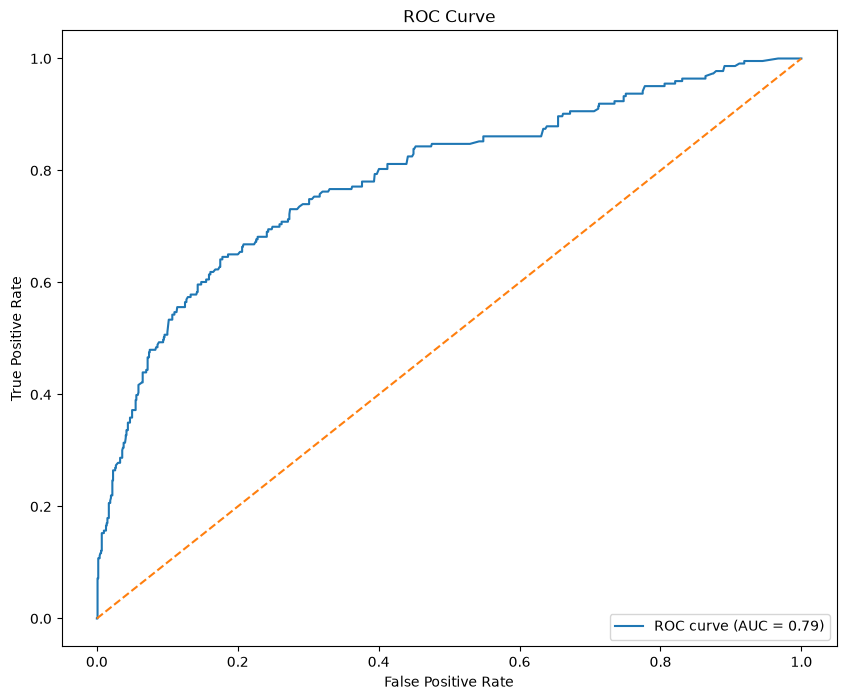

In [176]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc

fpr,tpr,threshold  = roc_curve(y_test,model.predict_proba(X_test_preprocessed)[:,1],pos_label=1)
r_auc = auc(fpr,tpr)

plt.figure(figsize=(10,8))

plt.plot(fpr,tpr,label = f"ROC curve (AUC = {r_auc:.2f})")

plt.plot([0,1],[0,1],linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()